# Package imports

In [9]:
# data manipulation
import numpy as np
import pandas as pd

# sklearn preprocessing for dealing with categorical variables
from sklearn.model_selection import StratifiedKFold, GridSearchCV, train_test_split
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    precision_recall_curve, auc,
    precision_score, recall_score, f1_score, make_scorer
)
from sklearn.preprocessing import StandardScaler


# Models used
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import lightgbm as lgb

# matplotlib and seaborn for plotting
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns

# For interpreting of models
import shap

# others
from itertools import product
from imblearn.pipeline import Pipeline  
from imblearn.over_sampling import SMOTE
from collections import Counter

# Suppress warnings 
import warnings
warnings.filterwarnings('ignore')

# Loading Datasets

In [10]:
final_df = pd.read_csv("final_dataset.csv")
final_df_lightgbm = pd.read_csv("final_dataset_for_lightgbm.csv")

# Tests naif de classification

In [ ]:
# List of strategies to test
strategies = ["most_frequent", "stratified", "uniform"]

# Séparer les features et la cible
X = final_df.drop(columns=["TARGET"])  # Replace "TARGET" with your target column
y = final_df["TARGET"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Loop on each DummyClassifier strategy
for strategy in strategies:
    print(f"\n🔹 Strategy : {strategy}")
    
    # Initialize and train DummyClassifier
    dummy_clf = DummyClassifier(strategy=strategy, random_state=42)
    dummy_clf.fit(X_train, y_train)
    
    # Predictions
    y_pred = dummy_clf.predict(X_test)
    
    # Evaluation metrics
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    # Confusion matrix
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    
    # Custom score
    custom_score = - ((fn * 10) + fp)
    
    # Display results
    print(f"Precision : {precision:.4f}")
    print(f"Recall : {recall:.4f}")
    print(f"F1-score : {f1:.4f}")
    print(f"Custom Score (FN * 10 + FP): {custom_score}")
    print("Classification Report:\n", classification_report(y_test, y_pred))



🔹 Stratégie : most_frequent
Précision : 0.0000
Rappel : 0.0000
F1-score : 0.0000
Custom Score (FN * 10 + FP): -49650
Classification Report:
               precision    recall  f1-score   support

           0       0.92      1.00      0.96     56538
           1       0.00      0.00      0.00      4965

    accuracy                           0.92     61503
   macro avg       0.46      0.50      0.48     61503
weighted avg       0.85      0.92      0.88     61503


🔹 Stratégie : stratified
Précision : 0.0837
Rappel : 0.0828
F1-score : 0.0832
Custom Score (FN * 10 + FP): -50041
Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.92      0.92     56538
           1       0.08      0.08      0.08      4965

    accuracy                           0.85     61503
   macro avg       0.50      0.50      0.50     61503
weighted avg       0.85      0.85      0.85     61503


🔹 Stratégie : uniform
Précision : 0.0809
Rappel : 0.5009
F1-scor

# Fonction de coût

In [11]:
# Custom score we will use to evaluate the performance of our model like we did with the DummyClassifier
def custom_cost_function(y_true, y_pred):
    """
    Custom cost function that further penalizes false negatives (FN).
    """
    from sklearn.metrics import confusion_matrix
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return -1 * (fn * 10 + fp)

custom_scorer = make_scorer(custom_cost_function, greater_is_better=False)

# Metrics

Functions to display scores

In [ ]:
# 📊 Metrics displaying
def display_metrics(y_true, y_pred):
    print("Custom Cost:", custom_cost_function(y_true, y_pred))
    print(f"Precision: {precision_score(y_true, y_pred):.4f}")
    print(f"Recall: {recall_score(y_true, y_pred):.4f}")
    print(f"F1-score: {f1_score(y_true, y_pred):.4f}")
    print("Classification Report:\n", classification_report(y_true, y_pred))

# 🧱 Confusion matrix
def plot_confusion_matrix(y_true, y_pred):
    conf_matrix = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues",
                xticklabels=["negative", "positive"],
                yticklabels=["negative", "positive"])
    plt.xlabel("Predictions")
    plt.ylabel("Real")
    plt.title("Confusion matrix")
    plt.show()

# 📈 Precision-Recall curve
def plot_precision_recall(y_true, y_scores):
    precision, recall, _ = precision_recall_curve(y_true, y_scores)
    pr_auc = auc(recall, precision)
    plt.figure(figsize=(6, 4))
    plt.plot(recall, precision, marker='.', label=f'PR AUC = {pr_auc:.2f}')
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title("Precision-Recall curve")
    plt.legend()
    plt.show()

# Regression Logisitique

Utilisons la régression logistique avec deux méthodes différentes d'équilibrage des classes.

Hyperparametres à optimiser:

**penalty :**	Type de régularisation : 'l1', 'l2', 'elasticnet', ou 'none' (intervient dans la fonction de coût)

**l1_ratio :**	Ratio entre L1 et L2 pour 'elasticnet'

**C :**	Force de la régularisation (inverse du paramètre de pénalisation λ) – plus C est grand, moins il y a de régularisation (intervient dans la fonction de coût)

**solver :**	Méthode d’optimisation : 'liblinear', 'lbfgs', 'newton-cg', 'saga'

**max_iter :**	Nombre max d’itérations pour la convergence

**class_weight :**	Gère le déséquilibre des classes : 'balanced' ou dictionnaire de poids

**fit_intercept :**	Est-ce qu’on apprend un biais (True) ou pas (False) ?

###  stratified cross validation + SMOTE + GreadSearchCV + custom score

🎯 Best Hyperparameters: {'C': 0.1, 'penalty': 'elasticnet', 'solver': 'saga', 'l1_ratio': 0.5, 'max_iter': 600, 'fit_intercept': False, 'warm_start': True, 'tol': 0.01}
Custom Cost: -35463
Precision: 0.1339
Recall: 0.8087
F1-score: 0.2298
Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.54      0.69     56538
           1       0.13      0.81      0.23      4965

    accuracy                           0.56     61503
   macro avg       0.55      0.67      0.46     61503
weighted avg       0.90      0.56      0.66     61503



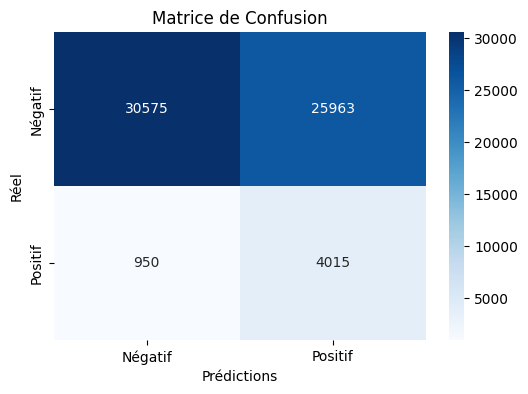

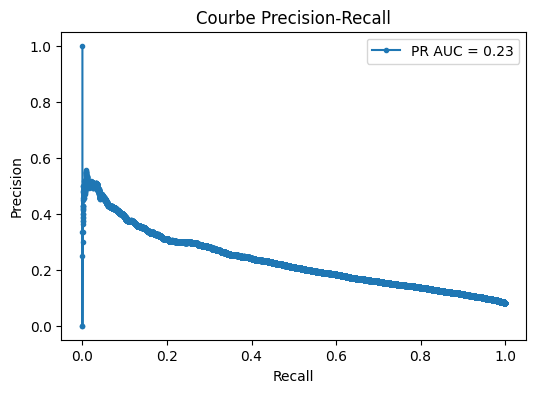

In [ ]:
# 📊 Metrics already defined earlier (display_metrics, plot_confusion_matrix, plot_precision_recall)

def optimize_logistic_regression(df, target="TARGET", test_size=0.2, random_state=42, param_grid={},sampling_strategy="smote"):
    """
    Manually optimizes hyperparameters for LogisticRegression using cross-validation.
    No Optuna; just a grid of parameters + SMOTE or class weights.
    """

    X = df.drop(columns=target)
    y = df[target]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, stratify=y, random_state=random_state
    )

    param_combinations = list(product(*param_grid.values()))
    param_names = list(param_grid.keys())

    best_score = -np.inf
    best_model = None
    best_params = None

    # 🧪 Manual grid search
    for combo in param_combinations:
        params = dict(zip(param_names, combo))

        # Skip invalid combos
        if params['penalty'] == 'l1' and params['solver'] not in ['liblinear', 'saga']:
            continue
        if params['penalty'] == 'elasticnet' and params['solver'] != 'saga':
            continue
        if params['penalty'] is None and params['solver'] not in ['lbfgs', 'newton-cg', 'saga']:
            continue
        if params['penalty'] != 'elasticnet' and params['l1_ratio'] != 0.0:
            continue

        clf = LogisticRegression(
            C=params['C'],
            penalty=params['penalty'],
            solver=params['solver'],
            l1_ratio=params['l1_ratio'] if params['penalty'] == 'elasticnet' else None,
            max_iter=params['max_iter'],
            fit_intercept=params['fit_intercept'],
            warm_start=params['warm_start'],
            tol=params['tol'],
            random_state=random_state,
            class_weight='balanced' if sampling_strategy == 'class_weight' else None
        )

        steps = [('scaler', StandardScaler())]
        if sampling_strategy == 'smote':
            steps.append(('smote', SMOTE(random_state=random_state)))
        steps.append(('classifier', clf))

        pipeline = Pipeline(steps)

        # Cross-validation
        skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=random_state)
        scores = []

        for train_idx, val_idx in skf.split(X_train, y_train):
            X_fold_train, X_fold_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
            y_fold_train, y_fold_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

            pipeline.fit(X_fold_train, y_fold_train)
            y_pred = pipeline.predict(X_fold_val)
            score = custom_cost_function(y_fold_val, y_pred)
            scores.append(score)

        mean_score = np.mean(scores)

        if mean_score > best_score:
            best_score = mean_score
            best_model = pipeline
            best_params = params

    # 📊 Final evaluation on test set
    best_model.fit(X_train, y_train)
    y_pred = best_model.predict(X_test)
    y_proba = best_model.predict_proba(X_test)[:, 1]

    print("🎯 Best Hyperparameters:", best_params)
    display_metrics(y_test, y_pred)
    plot_confusion_matrix(y_test, y_pred)
    plot_precision_recall(y_test, y_proba)

    return best_model, best_params, best_score


param_grid = {
        'C': [0.1],
        'penalty': ['elasticnet'],
        'solver': ['saga'],
        'l1_ratio': [0.5],
        'max_iter': [600],
        'fit_intercept': [False],
        'warm_start': [True],
        'tol': [1e-2],
    }

# Apply on dataset (final_df)
model, params, score = optimize_logistic_regression(final_df, target="TARGET", param_grid=param_grid ,sampling_strategy="smote")


# Best result so far with smote
# Meilleurs hyperparamètres : {'classifier__C': 0.1, 'classifier__fit_intercept': False, 'classifier__l1_ratio': 0.5, 'classifier__max_iter': 600, 'classifier__penalty': 'elasticnet', 'classifier__solver': 'saga', 'classifier__tol': 0.01, 'classifier__warm_start': True}
# Custom Cost: -35463
# Precision: 0.1339
# Recall: 0.8087
# F1-score: 0.2298
# PR AUC : 0.23


### stratified cross validation + Class Weights + GreadSearchCV + custom score

🎯 Best Hyperparameters: {'C': 0.1, 'penalty': 'elasticnet', 'solver': 'saga', 'l1_ratio': 0.5, 'max_iter': 600, 'fit_intercept': False, 'warm_start': True, 'tol': 0.01}
Custom Cost: -34492
Precision: 0.1380
Recall: 0.8129
F1-score: 0.2360
Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.55      0.71     56538
           1       0.14      0.81      0.24      4965

    accuracy                           0.58     61503
   macro avg       0.55      0.68      0.47     61503
weighted avg       0.90      0.58      0.67     61503



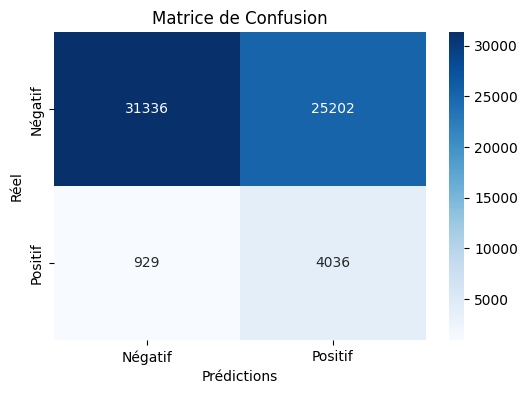

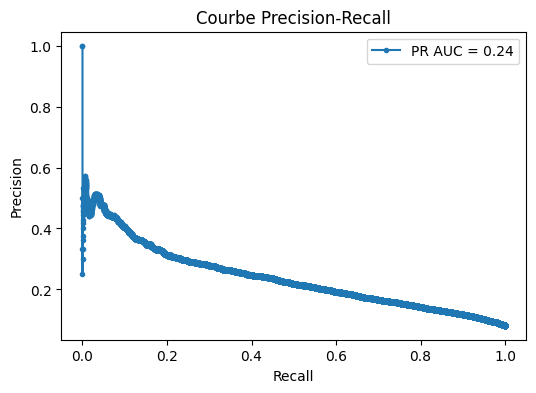

In [ ]:
# Using the same  previous function with changing the sampling strategy to class_weight

param_grid = {
        'C': [0.1],
        'penalty': ['elasticnet'],
        'solver': ['saga'],
        'l1_ratio': [0.5],
        'max_iter': [600],
        'fit_intercept': [False],
        'warm_start': [True],
        'tol': [1e-2],
    }
model, params, score = optimize_logistic_regression(final_df, target="TARGET", param_grid=param_grid,sampling_strategy="class_weight")

# best result so far with class_weight
# Meilleurs hyperparamètres : {'classifier__C': 0.1, 'classifier__class_weight': 'balanced', 'classifier__fit_intercept': False, 'classifier__l1_ratio': 0.5, 'classifier__max_iter': 600, 'classifier__penalty': 'elasticnet', 'classifier__solver': 'saga', 'classifier__tol': 0.01, 'classifier__warm_start': True}
# Coût personnalisé (FN pénalisés) : -34492
# Précision : 0.1380
# Rappel : 0.8129
# F1-score : 0.2360
# PR AUC : 0.24

# RandomnForest

## SMOTE version

With all the previous treatement (k-stratifiedvalidation, cost function, greadsearch)

In [ ]:
def optimize_random_forest(df, target="TARGET", test_size=0.2, random_state=42, param_grid=None, sampling_method="smote", cv_folds=3):
    """
    Optimizes a Random Forest classifier using SMOTE or class_weight='balanced',
    StratifiedKFold, and GridSearchCV on a full dataset.

    Parameters:
        df (pd.DataFrame): Full dataset including features and target.
        target (str): Name of the target column.
        test_size (float): Proportion of the test set. Default is 0.2.
        random_state (int): Seed for reproducibility.
        param_grid (dict): Dictionary of hyperparameters for GridSearchCV.
        sampling_method (str): "smote" or "class_weight". Default is "smote".
        cv_folds (int): Number of cross-validation folds.

    Returns:
        best_model (Pipeline): Best pipeline after GridSearchCV.
        best_params (dict): Best hyperparameters found.
    """

    from sklearn.model_selection import train_test_split

    X = df.drop(columns=target)
    y = df[target]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, stratify=y, random_state=random_state
    )

    base_model = RandomForestClassifier(
        oob_score=True,
        n_jobs=-1,
        random_state=random_state,
        verbose=1,
        warm_start=False,
    )

    if sampling_method == "class_weight":
        base_model.set_params(class_weight='balanced')

    if sampling_method == "smote":
        pipeline = Pipeline([
            ('scaler', StandardScaler()),
            ('smote', SMOTE(random_state=random_state)),
            ('classifier', base_model)
        ])
    elif sampling_method == "class_weight":
        pipeline = Pipeline([
            ('scaler', StandardScaler()),
            ('classifier', base_model)
        ])
    else:
        raise ValueError("sampling_method must be either 'smote' or 'class_weight'")

    skf = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=random_state)

     # Dynamically update param_grid for class_weight search
    if sampling_method == "class_weight" and param_grid is not None:
        if 'classifier__class_weight' not in param_grid:
            param_grid['classifier__class_weight'] = [None, 'balanced']

    grid_search = GridSearchCV(
        pipeline,
        param_grid=param_grid,
        cv=skf,
        scoring=custom_scorer,
        n_jobs=-1,
        verbose=2
    )

    grid_search.fit(X_train, y_train)
    best_model = grid_search.best_estimator_
    best_params = grid_search.best_params_

    print("🎯 Best hyperparameters :", best_params)
    print("📉 best score (customized cost function) :", grid_search.best_score_)

    y_pred = best_model.predict(X_test)
    y_proba = best_model.predict_proba(X_test)[:, 1]

    display_metrics(y_test, y_pred)
    plot_confusion_matrix(y_test, y_pred)
    plot_precision_recall(y_test, y_proba)

    return best_model, best_params


Fitting 3 folds for each of 1 candidates, totalling 3 fits


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 32 concurrent workers.
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:  2.4min finished


🎯 Meilleurs hyperparamètres : {'classifier__bootstrap': True, 'classifier__ccp_alpha': 0.01, 'classifier__criterion': 'entropy', 'classifier__max_depth': None, 'classifier__max_features': 'sqrt', 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 100}
📉 Meilleur score (fonction de coût personnalisée) : 63787.333333333336


[Parallel(n_jobs=32)]: Using backend ThreadingBackend with 32 concurrent workers.
[Parallel(n_jobs=32)]: Done 100 out of 100 | elapsed:    0.0s finished
[Parallel(n_jobs=32)]: Using backend ThreadingBackend with 32 concurrent workers.
[Parallel(n_jobs=32)]: Done 100 out of 100 | elapsed:    0.0s finished


Custom Cost: -48947
Precision: 0.2170
Recall: 0.0222
F1-score: 0.0402
Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.99      0.96     56538
           1       0.22      0.02      0.04      4965

    accuracy                           0.91     61503
   macro avg       0.57      0.51      0.50     61503
weighted avg       0.86      0.91      0.88     61503



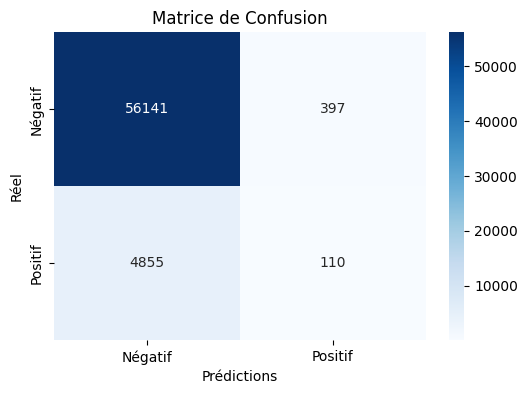

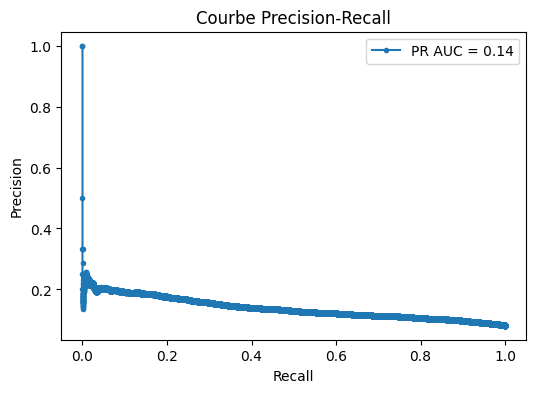

In [ ]:
param_grid = {
    'classifier__n_estimators': [100],
    'classifier__max_features': ['sqrt'],
    'classifier__criterion': ['entropy'],
    'classifier__bootstrap': [True],
    'classifier__max_depth': [None],
    'classifier__min_samples_split': [2],
    'classifier__min_samples_leaf': [1],
    'classifier__ccp_alpha': [0.01],
    # 'classifier__class_weight' will be added automatically if needed
}

# Using SMOTE
best_model, best_params = optimize_random_forest(df=final_df, target="TARGET", sampling_method="smote", param_grid=param_grid)

# best result
# Custom Cost: -48947
# Precision: 0.2170
# Recall: 0.0222
# F1-score: 0.0402
# PR AUC : 0.14

## Class_weight version

With all the previous treatement (k-stratifiedvalidation, cost function, greadsearch)

Fitting 3 folds for each of 2 candidates, totalling 6 fits


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 32 concurrent workers.
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:   15.4s finished


🎯 Meilleurs hyperparamètres : {'classifier__bootstrap': True, 'classifier__ccp_alpha': 0.01, 'classifier__class_weight': None, 'classifier__criterion': 'entropy', 'classifier__max_depth': None, 'classifier__max_features': 'sqrt', 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 100}
📉 Meilleur score (fonction de coût personnalisée) : 66200.0


[Parallel(n_jobs=32)]: Using backend ThreadingBackend with 32 concurrent workers.
[Parallel(n_jobs=32)]: Done 100 out of 100 | elapsed:    0.0s finished
[Parallel(n_jobs=32)]: Using backend ThreadingBackend with 32 concurrent workers.
[Parallel(n_jobs=32)]: Done 100 out of 100 | elapsed:    0.0s finished


Custom Cost: -49650
Precision: 0.0000
Recall: 0.0000
F1-score: 0.0000
Classification Report:
               precision    recall  f1-score   support

           0       0.92      1.00      0.96     56538
           1       0.00      0.00      0.00      4965

    accuracy                           0.92     61503
   macro avg       0.46      0.50      0.48     61503
weighted avg       0.85      0.92      0.88     61503



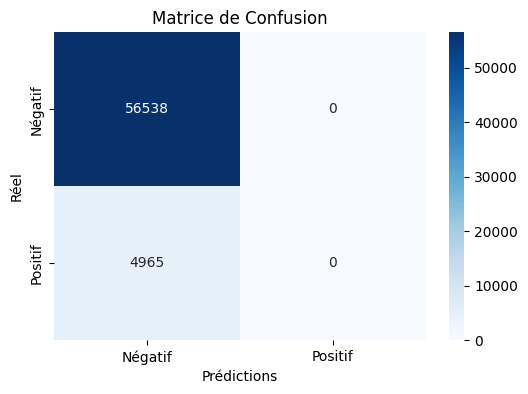

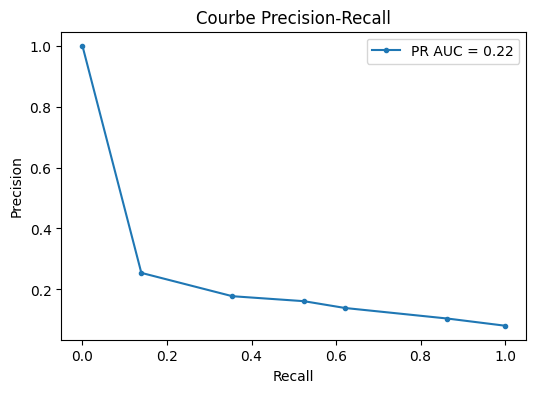

In [ ]:
param_grid = {
    'classifier__n_estimators': [100],
    'classifier__max_features': ['sqrt'],
    'classifier__criterion': ['entropy'],
    'classifier__bootstrap': [True],
    'classifier__max_depth': [None],
    'classifier__min_samples_split': [2],
    'classifier__min_samples_leaf': [1],
    'classifier__ccp_alpha': [0.01],
    # 'classifier__class_weight' will be added automatically if needed
}
# Using class_weight
best_model, best_params = optimize_random_forest(df=final_df, target="TARGET", sampling_method="class_weight", param_grid=param_grid)

# best result
# Custom Cost: -49650
# Precision: 0.0000
# Recall: 0.0000
# F1-score: 0.0000
# PR AUC : 0.22

# LightGBM

## LightGBM with imputed missing values

LightGBM: Smote vs scale_pos_weight

In [ ]:
# ⚙️ Grid Search with LightGBM (GPU) and optional SMOTE
def lightgbm_cv(X, y, param_grid, use_smote=False, cv_folds=3):
    """
    Runs GridSearchCV with LightGBM (GPU) + SMOTE or scale_pos_weight.

    Args:
        X (pd.DataFrame): Features.
        y (pd.Series): Target.
        param_grid (dict): Grid search hyperparameters.
        use_smote (bool): Whether to use SMOTE oversampling.
        cv_folds (int): Number of cross-validation folds.

    Returns:
        best_model: Best estimator pipeline.
        best_params: Best hyperparameters.
    """

    # ⚖️ Resampling or weighting
    if use_smote:
        X, y = SMOTE(random_state=42).fit_resample(X, y)
        scale_pos_weight = None
    else:
        class_counts = Counter(y)
        scale_pos_weight = class_counts[0] / class_counts[1]

    # 🛠️ Pipeline
    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("classifier", lgb.LGBMClassifier(
            random_state=42,
            device='gpu',
            gpu_platform_id=0,
            gpu_device_id=0,
            scale_pos_weight=scale_pos_weight
        ))
    ])

    # 🎯 Cross-validation strategy
    skf = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=42)

    # 🔍 Grid search
    grid_search = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grid,
        cv=skf,
        scoring=custom_scorer,
        n_jobs=-1,
        verbose=2
    )

    # 🔁 Training
    grid_search.fit(X, y)

    best_model = grid_search.best_estimator_
    best_params = grid_search.best_params_
    
    y_pred = best_model.predict(X_test)
    y_proba = best_model.predict_proba(X_test)[:, 1]

    display_metrics(y_test, y_pred)
    plot_confusion_matrix(y_test, y_pred)
    plot_precision_recall(y_test, y_proba)

    
    print("\n✅ Best Hyperparameters:", best_params)
    return best_model, best_params


Smote

Fitting 3 folds for each of 1 candidates, totalling 3 fits
[LightGBM] [Info] Number of positive: 226148, number of negative: 226148
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 125174
[LightGBM] [Info] Number of data points in the train set: 452296, number of used features: 636
[LightGBM] [Info] Using requested OpenCL platform 0 device 0
[LightGBM] [Info] Using GPU Device: Intel(R) RaptorLake-S Mobile Graphics Controller, Vendor: Intel(R) Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 256 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Info] Size of histogram bin entry: 8
[LightGBM] [Info] 358 dense feature groups (155.28 MB) transferred to GPU in 0.059526 secs. 1 sparse feature groups
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
Custom Cost: -46334
Precision: 0.1319
Recall: 0.1954
F1-score: 0.1575
Classification Report:
               precision    recall  f1-score   support

           0      

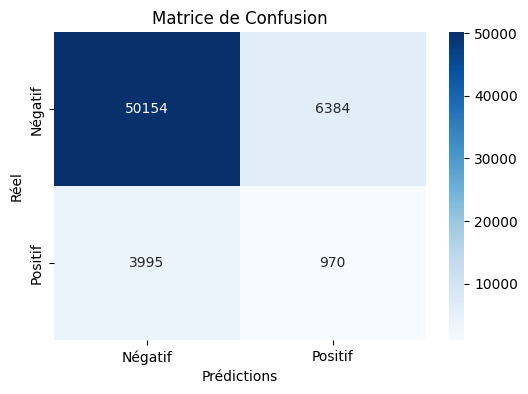

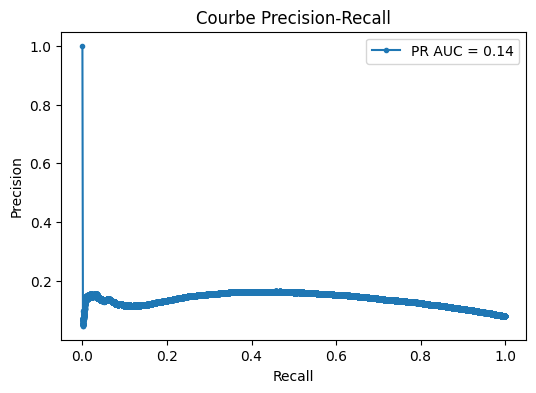


✅ Best Hyperparameters: {'classifier__boosting_type': 'gbdt', 'classifier__colsample_bytree': 0.6, 'classifier__learning_rate': 1, 'classifier__max_depth': -1, 'classifier__min_child_samples': 50, 'classifier__n_estimators': 50, 'classifier__num_leaves': 31, 'classifier__reg_alpha': 0.0, 'classifier__reg_lambda': 0.1, 'classifier__subsample': 0.6}


In [ ]:
# 📌 Hyperparameter definition for GridSearchCV
param_grid = {
    'classifier__num_leaves': [31],
    'classifier__learning_rate': [1],
    'classifier__n_estimators': [50],
    'classifier__max_depth': [-1],
    'classifier__boosting_type': ['gbdt'],  # ou ['gbdt', 'dart'] pour tester les deux
    'classifier__min_child_samples': [50],
    'classifier__subsample': [0.6],  # aka bagging_fraction
    'classifier__colsample_bytree': [0.6],  # aka feature_fraction
    'classifier__reg_alpha': [0.0],  # L1
    'classifier__reg_lambda': [0.1]  # L2
}

best_model_smote, best_params_smote = lightgbm_cv(X_train, y_train, param_grid, use_smote=True)

# Best hyperparameters: {'classifier__boosting_type': 'gbdt', 'classifier__learning_rate': 1, 'classifier__max_depth': -1, 'classifier__n_estimators': 50, 'classifier__num_leaves': 31}
# Custom Cost: -46334
# Precision: 0.1319
# Recall: 0.1954
# F1-score: 0.1575
# PR AUC: 0.14

Clas_weights

Fitting 3 folds for each of 1 candidates, totalling 3 fits
[LightGBM] [Info] Number of positive: 19860, number of negative: 226148
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 29000
[LightGBM] [Info] Number of data points in the train set: 246008, number of used features: 633
[LightGBM] [Info] Using requested OpenCL platform 0 device 0
[LightGBM] [Info] Using GPU Device: Intel(R) RaptorLake-S Mobile Graphics Controller, Vendor: Intel(R) Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 256 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Info] Size of histogram bin entry: 8
[LightGBM] [Info] 316 dense feature groups (74.14 MB) transferred to GPU in 0.043123 secs. 1 sparse feature groups
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080729 -> initscore=-2.432482
[LightGBM] [Info] Start training from score -2.432482
Custom Cost: -30685
Precision: 0.1821
Recall: 0.6935
F1-score: 0.2884
Classification Report:
               precisi

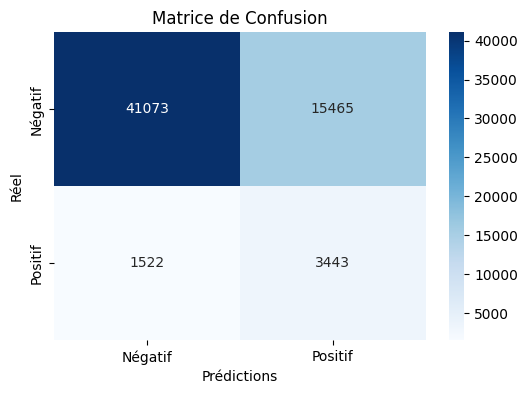

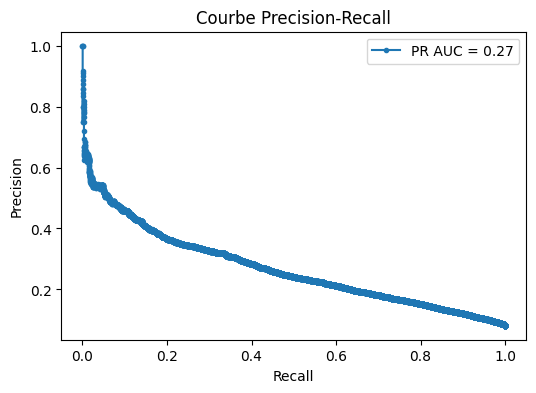


✅ Best Hyperparameters: {'classifier__boosting_type': 'gbdt', 'classifier__colsample_bytree': 0.6, 'classifier__learning_rate': 0.1, 'classifier__max_depth': -1, 'classifier__min_child_samples': 50, 'classifier__n_estimators': 100, 'classifier__num_leaves': 31, 'classifier__reg_alpha': 0, 'classifier__reg_lambda': 0.1, 'classifier__subsample': 0.6}


In [ ]:
# 📌 Hyperparameter definition for GridSearchCV
param_grid = {
    'classifier__num_leaves': [31],
    'classifier__learning_rate': [0.1],
    'classifier__n_estimators': [100],
    'classifier__max_depth': [-1],
    'classifier__boosting_type': ['gbdt'],  # ou ['gbdt', 'dart'] pour tester les deux
    'classifier__min_child_samples': [50],
    'classifier__subsample': [0.6],  # aka bagging_fraction
    'classifier__colsample_bytree': [0.6],  # aka feature_fraction
    'classifier__reg_alpha': [0],  # L1   0.0, 0.1, 1.0
    'classifier__reg_lambda': [0.1]  # L2  0.0, 0.1, 1.0
}

best_model_weighted, best_params_weighted = lightgbm_cv(X_train, y_train, param_grid, use_smote=False)

# Best hyperparameters: {'classifier__boosting_type': 'gbdt', 'classifier__colsample_bytree': 0.6, 'classifier__learning_rate': 0.1, 'classifier__max_depth': -1, 'classifier__min_child_samples': 50, 'classifier__n_estimators': 100, 'classifier__num_leaves': 31, 'classifier__reg_alpha': 0.0, 'classifier__reg_lambda': 0.1, 'classifier__subsample': 0.6}
# Custom score: -30685
# Precision: 0.1821
# Recall: 0.6935
# F1-score: 0.2884
# PR AUC: 0.27 

LightGBM mais avec les valeurs manquantes dans le dataset

## LightGBM with minimal treatement (with missing values and categorical columns)

Fitting 3 folds for each of 1 candidates, totalling 3 fits
[LightGBM] [Warning] categorical_feature is set=code_gender,name_type_suite,name_income_type,name_education_type,name_family_status,name_housing_type,occupation_type,weekday_appr_process_start,organization_type,fondkapremont_mode,housetype_mode,wallsmaterial_mode,buro_credit_active_get_mode,buro_credit_currency_get_mode,buro_credit_type_get_mode,buro_status_get_mode_get_mode,prev_approved_name_contract_type_get_mode,prev_approved_weekday_appr_process_start_get_mode,prev_approved_name_cash_loan_purpose_get_mode,prev_approved_na
[LightGBM] [Info] Number of positive: 19860, number of negative: 226148
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 32786
[LightGBM] [Info] Number of data points in the train set: 246008, number of used features: 249
[LightGBM] [Info] Using requested OpenCL platform 1 device 0
[LightGBM] [Info] Using GPU Device: NVIDIA GeForce RTX 4060 Laptop GPU, Vendor: NVIDIA Corporation
[L

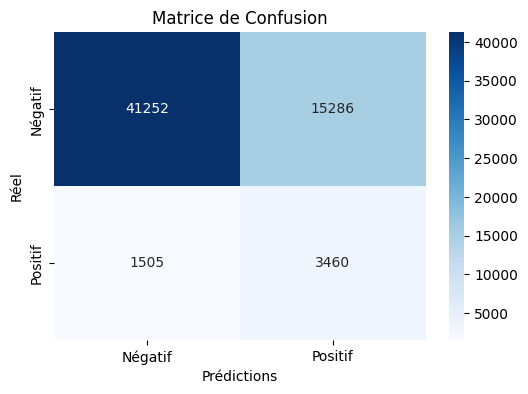

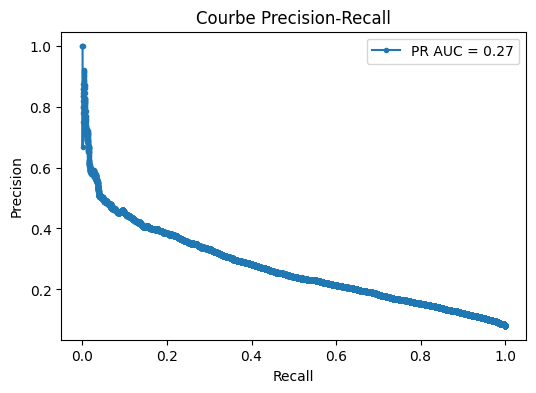

In [ ]:
def lightgbm_cv_full_data(df, target_column, param_grid, test_size=0.2, cv_folds=3):
    """
    GridSearchCV + StratifiedKFold on LightGBM with automatic management of categorical features
    and weighting of classes (scale_pos_weight). Displays metrics and curves at the end.
    """

    # Splitting X/y
    X = df.drop(columns=[target_column])
    y = df[target_column]

    # Cleaning column names
    X.columns = X.columns.str.strip().str.replace(r'[^\w]', '_', regex=True).str.lower()

    # Explicit conversion of object columns to categories
    for col in X.select_dtypes(include='object').columns:
        X[col] = X[col].astype('category')
    categorical_cols = X.select_dtypes(include='category').columns.tolist()

    # Stratified split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, stratify=y, random_state=42
    )

    # Calculating of scale_pos_weight
    class_counts = Counter(y_train)
    scale_pos_weight = class_counts[0] / class_counts[1]

    # LightGBM model
    classifier = lgb.LGBMClassifier(
        random_state=42,
        scale_pos_weight=scale_pos_weight,
        categorical_feature=categorical_cols,
        device='gpu',
        gpu_platform_id=1,
        gpu_device_id=0
    )

    # Pipeline
    pipeline = Pipeline([
        ('classifier', classifier)
    ])

    # Customized cost function
    scorer = make_scorer(custom_cost_function, greater_is_better=False)

    # Cross-validation
    skf = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=42)

    # GridSearchCV
    grid_search = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grid,
        scoring=scorer,
        cv=skf,
        n_jobs=-1,
        verbose=2
    )

    # Training
    grid_search.fit(X_train, y_train)

    # Results
    best_model = grid_search.best_estimator_
    best_params = grid_search.best_params_

    print(f"✅ Meilleurs hyperparamètres : {best_params}")

    # Predictions
    y_pred = best_model.predict(X_test)
    y_proba = best_model.predict_proba(X_test)[:, 1]

    # 📊 Display the results
    display_metrics(y_test, y_pred)
    plot_confusion_matrix(y_test, y_pred)
    plot_precision_recall(y_test, y_proba)

    # ⬅️ We also return the list of categorical columns
    return best_model, best_params, categorical_cols


param_grid = {
    'classifier__num_leaves': [31],
    'classifier__learning_rate': [ 0.1],
    'classifier__n_estimators': [105],
    'classifier__max_depth': [-1],
    'classifier__boosting_type': ['gbdt'],  # ou ['gbdt', 'dart'] pour tester les deux
    'classifier__min_child_samples': [45],
    'classifier__subsample': [0.6],  # aka bagging_fraction
    'classifier__colsample_bytree': [0.6],  # aka feature_fraction
    'classifier__reg_alpha': [0.0],  # L1
    'classifier__reg_lambda': [0.1],  # L2
    #'classifier__min_split_gain': [0.0222415],
}

best_model, best_params, categorical_cols = lightgbm_cv_full_data(final_df_lightgbm, target_column='TARGET', param_grid=param_grid)

# Custom score : -36691 (results with micheal kaggle parameters values)
# Precision: 0.2718
# Recall: 0.3565
# F1-score: 0.3085
# PR AUC: 0.25

# ✅ Best hyperparameters: {'classifier__boosting_type': 'gbdt', 'classifier__colsample_bytree': 0.6, 'classifier__learning_rate': 0.1, 'classifier__max_depth': -1, 'classifier__min_child_samples': 45, 'classifier__n_estimators': 105, 'classifier__num_leaves': 31, 'classifier__reg_alpha': 0.0, 'classifier__reg_lambda': 0.1, 'classifier__subsample': 0.6}
# Custom score : -30335
# Precision: 0.1846
# Recall: 0.6969
# F1-score: 0.2919
# PR AUC: 0.27




# Comparison of results

Let show all the resultats we got from previous tests of models:

| Model                                               | Custom function | Precision | Recall | F1-score | PR-AUC |
|-----------------------------------------------------|-----------------|-----------|--------|----------|--------|
| Dummy classifier with most_frequent strategy        | -49650          | 0.0000    | 0.0000 | 0.0000   |        |
| Dummy classifier with stratified strategy           | -50041          | 0.0837    | 0.0828 | 0.0832   |        |
| Dummy classifier with uniform strategy              | -53018          | 0.0809    | 0.5009 | 0.1394   |        |
| Logistic Regression with SMOTE                      | -35463          | 0.1339    | 0.8087 | 0.2298   | 0.23   |
| Logistic Regression with ClassWeights               | -34492          | 0.1380    | **0.8129** | 0.2360   | 0.24   |
| Random Forest with SMOTE                            | -48947          | **0.2170**    | 0.0222 | 0.0402   | 0.14   |
| Random Forest with ClassWeights                     | -49650          | 0.0000    | 0.0000 | 0.0000   | 0.22   |
| LightGBM: Smote                                     | -46334          | 0.1319    | 0.1954 | 0.1575   | 0.14   |
| LightGBM scale_pos_weight                           | -30685          | 0.1821    | 0.6935 | 0.2884   | **0.27**   |
| LightGBM (with missing values and not encoded vars) | **-30335**          | 0.1846    | 0.6969 | **0.2919**   | **0.27**   |

From those results, the model we choose as best model is the last one 'LightGBM (with missing values and not encoded vars)'

# SHAPE

## Global

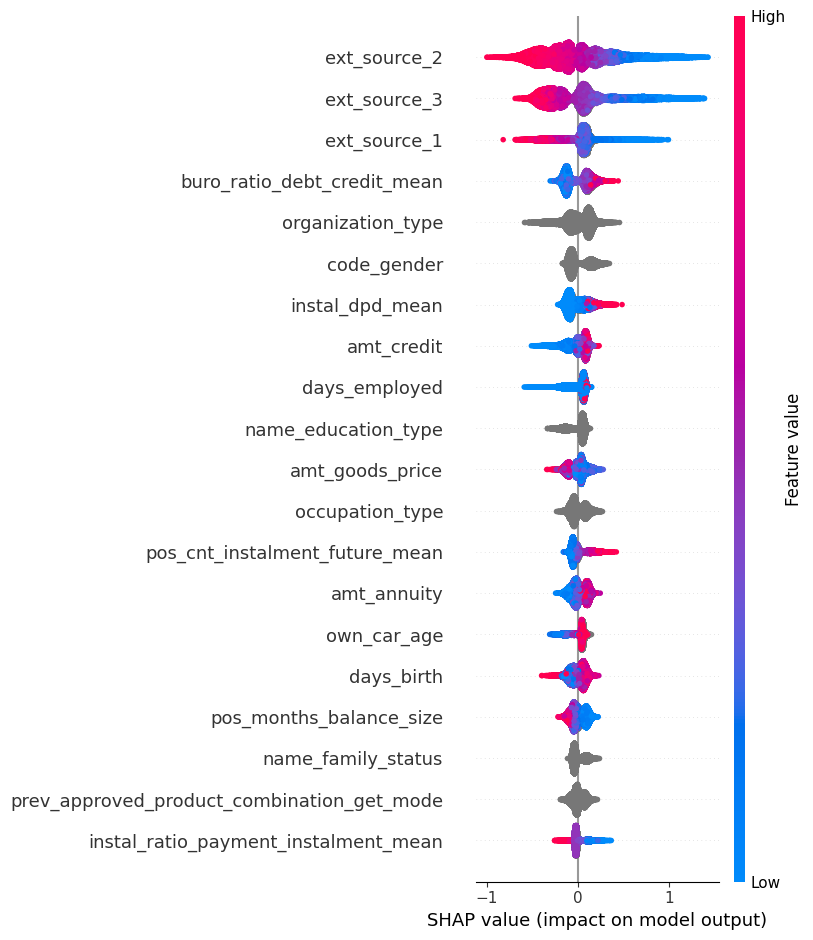

In [ ]:
# 🔍 Extract LightGBM model from pipeline
lgb_model = best_model.named_steps['classifier']


# 🔍 Split of X_test as before
X = final_df_lightgbm.drop(columns=['TARGET'])
_, X_test, _, _ = train_test_split(X, final_df_lightgbm['TARGET'], test_size=0.2, stratify=final_df_lightgbm['TARGET'], random_state=42)

# ✅ Cleaning consistent with model preprocessing
X_test.columns = X_test.columns.str.strip().str.replace(r'[^\w]', '_', regex=True).str.lower()

# ✅ Apply 'category' types to the right columns
for col in categorical_cols:
    if col in X_test.columns:
        X_test[col] = X_test[col].astype('category')

X_test_final = X_test.copy()

# ✅ Extract native booster
booster = lgb_model.booster_

# ✅ Create SHAP explainer
explainer = shap.TreeExplainer(booster)

# ✅ Compute SHAP values
shap_values = explainer.shap_values(X_test_final)

# ✅ SHAP summary plot
shap.summary_plot(shap_values, features=X_test_final, feature_names=X_test_final.columns)



🧠 **What this graph shows ?**

* **Y-axis** : The **20 most important variables** for the model.
* **X-axis** : The **SHAP values**, that is to say **the impact of each variable** on the model output (positive = to 1, negative = to 0).
* **Colors** :

  * 🔴 **Red = variable high value**
  * 🔵 **Blue = low value**
  * ⚫️ **Grey = categorical or missing value**

---

🔍 **Interpretation on some variables**

1. **`ext_source_2`, `ext_source_3`, `ext_source_1`**

   * These are external scores (often credit scores or socio-economic indicators).
   * **High value (red)**   **negative impact** on output so **reduces risk**.
   * **Low value (blue)**   **positive impact**   **increases risk**.
   * 💡 **Conclusion:** the higher the score, the lower the probability of default.

2. **`buro_ratio_debt_credit_mean`**

   * Ratio between debt and credit in the credit bureau.
   * **High ratio (red)** tends to **increase risk (positive impact)**.

3. **`organization_type` et `code_gender`**

   * Categorical variables. The effect depends on the modality (shown here in grey).
   * Some terms are associated with a **higher risk**, others with a **reduced risk**.

4. **`instal_dpd_mean`**

   * Average days of late payment on previous credits.
   * **High value** (frequent delays)   **positive impact (increased risk)**.
   * **Low value (blue)**   more confident model (negative impact).

5. **`amt_credit`, `amt_goods_price`, `amt_annuity`**

   * Amounts of credits, assets or annuities.
   * Their effect varies (not unidirectional), suggesting that they interact with other variables.

6. **`days_employed`, `days_birth`**

   * **`days_employed`** (number of days worked) :

     * **Low (blue)**   increased risk (positive effect)
     * **High (red)**   stabilizes the score.
   * **`days_birth`** = age (the lower the value, the older the person)

     * Younger people (values high in red) tend to increase the risk.

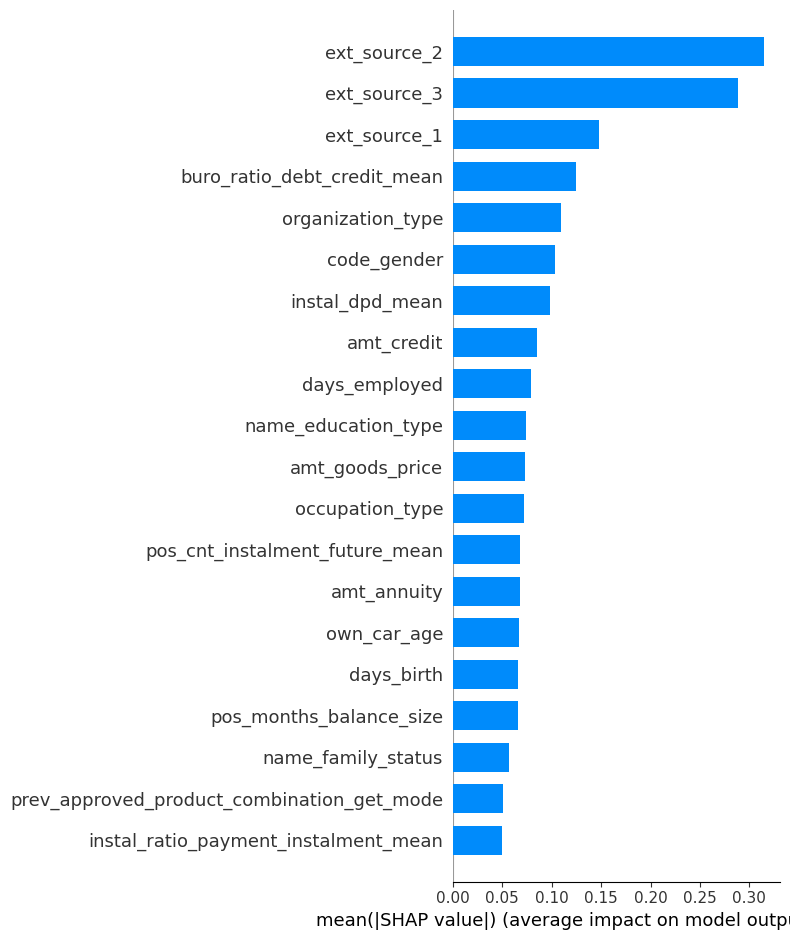

In [32]:
# ✅ SHAP summary bar plot (mean absolute SHAP value)
shap.summary_plot(
    shap_values,
    features=X_test_final,
    feature_names=X_test_final.columns,
    plot_type="bar"

)

this summary (with bars instead of dots shows us the contribution of each variable , but the first summary is better because it shows us  more detail about the impact a variable does have)

## Local

In [15]:
print(type(shap_values))
if isinstance(shap_values, list):
    print("Binary classification: shap_values is a list of", len(shap_values), "elements")
    print("Type of explainer.expected_value:", type(explainer.expected_value))
else:
    print("shap_values shape:", np.shape(shap_values))
    print("explainer.expected_value:", explainer.expected_value)


<class 'numpy.ndarray'>
shap_values shape: (61503, 262)
explainer.expected_value: -0.5771531984971898


Let study the feature importance for the first instance in test set ( with index 0)

### Bar Plot

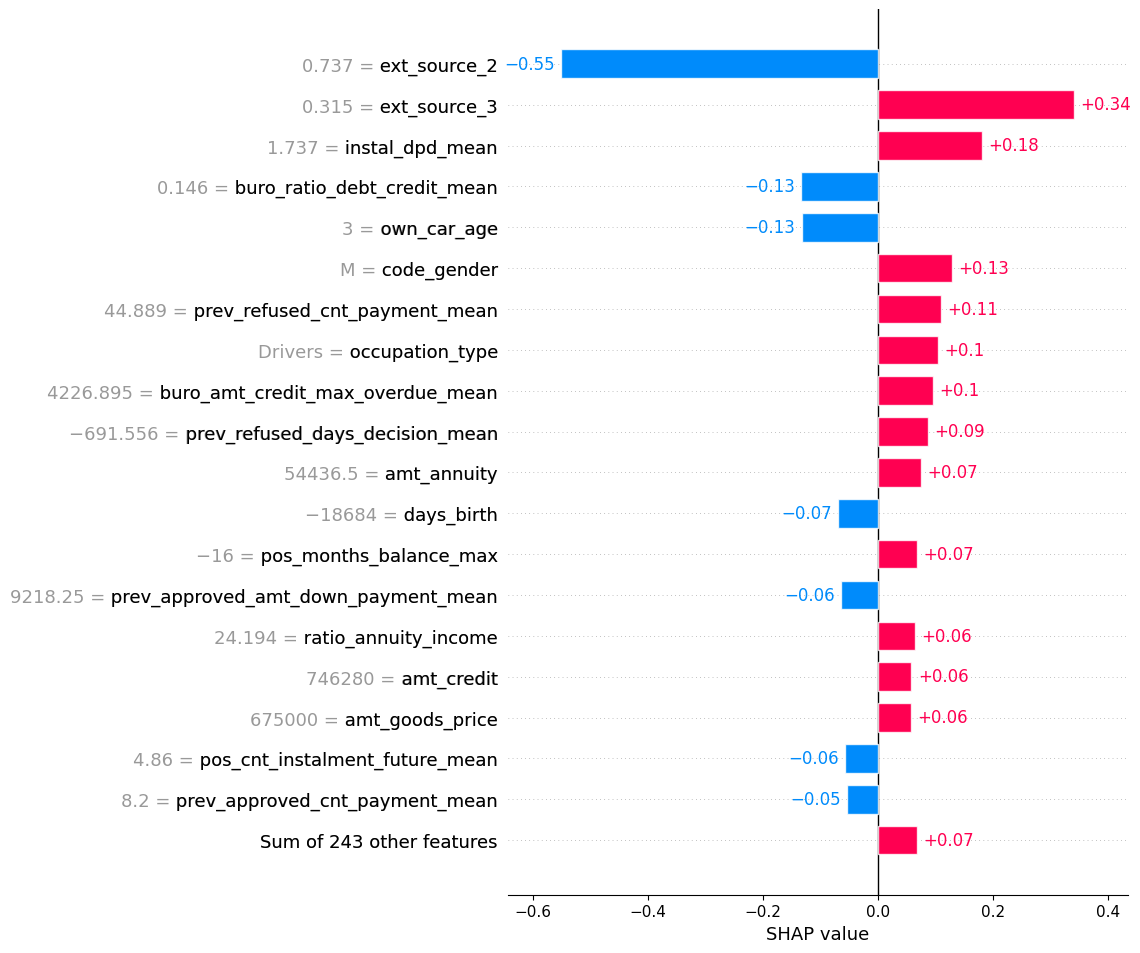

In [ ]:
# Selection of instance 0
instance_index = 0
x_instance = X_test_final.iloc[instance_index]

# If shap_values is a 2D array (n_samples, n_features)
shap_values_instance = shap_values[instance_index]

# BarPlot local SHAP
shap.plots.bar(shap.Explanation(
    values=shap_values_instance,
    base_values=explainer.expected_value,
    data=x_instance,
    feature_names=X_test_final.columns
), max_display=20, show=True)



### Force plot

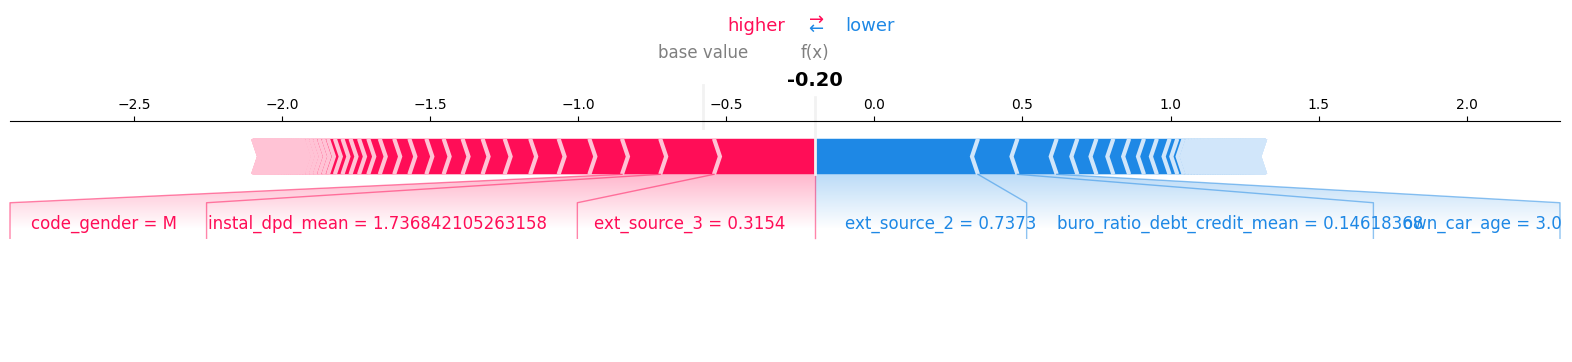

In [ ]:
# Initialization JS if you are in notebook
shap.initjs()

# Index of the individual to explain
i = 0

# Force plot
shap.force_plot(
    explainer.expected_value,
    shap_values[i],
    X_test_final.iloc[i],
    matplotlib=True
)



🎯 **Interpretation**

1. **Colors**

* 🔴 **Red**: features that **increase** the prediction (to the right).
* 🔵 **Blue**: features that **decrease** the prediction (to the left).

> In binary classification, a higher score **high** corresponds to a higher **probability** for the positive **class**.

---

2. ***Linear reading**

* The model **part of the base value** ( -0.577).
* It **adds/subtracts** each SHAP value (feature) one after the other.
* It **ends at -0.20**, which is the final output before transformation (proba si sigmoid).

3. **Example in your plot**

🔴 *** Features that increase risk** (`f(x)` becomes less negative = closer to 0 = more "positive"):

| Feature                  | Value                                     | Effect  |
| ------------------------ | ------------------------------------------- | ------ |
| `code_gender = M`        | 'Masculin' (male)                           | ⬆ f(x) |
| `instal_dpd_mean = 1.73` | Average payment delays quite high           | ⬆ f(x) |
| `ext_source_3 = 0.3154`  | Low external score                          | ⬆ f(x) |

🔵 **Features that reduce risk** (draw the prediction to the left = class 0) :

| Feature                               | Valeur                          | Effet  |
| ------------------------------------- | ------------------------------- | ------ |
| `ext_source_2 = 0.7373`               | Good external score             | ⬇ f(x) |
| `buro_ratio_debt_credit_mean = 0.146` | Moderate debt/credit ratio      | ⬇ f(x) |
| `own_car_age = 3`                     | Ownership of a "young vehicle   | ⬇ f(x) |

---

📈 What does the score  `f(x) = -0.20` mean ?

It is a **logit** (log-odds), so you have to convert it into probability:

```python
from scipy.special import expit
prob = expit(-0.20)
print(prob)  # ≈ 0.45
```

So: ** the model predicts 45% chance that this individual is in the positive class** (TARGET = 1).

### Decision plot

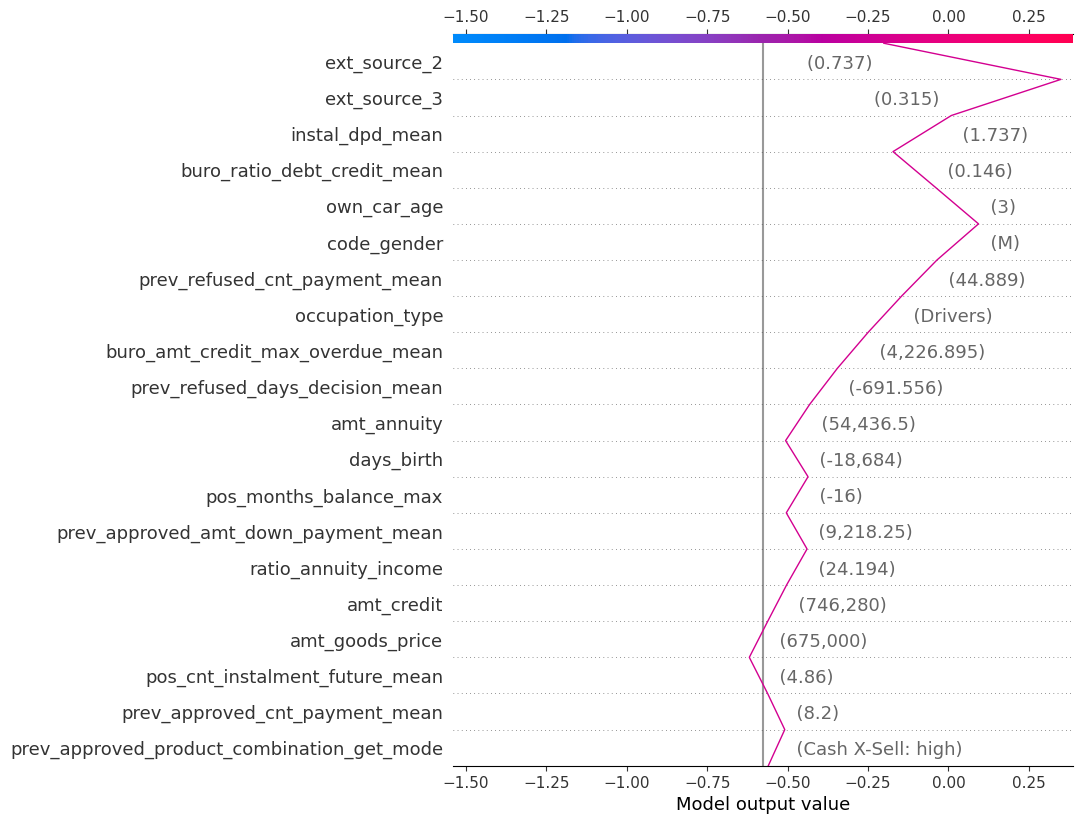

In [ ]:
# Decision plot for a single individual (e.g., 0e)
shap.decision_plot(
    explainer.expected_value,       
    shap_values[0],                 
    X_test_final.iloc[0],              
    #feature_names=X_test_final.columns
)


### Waterfoll plot

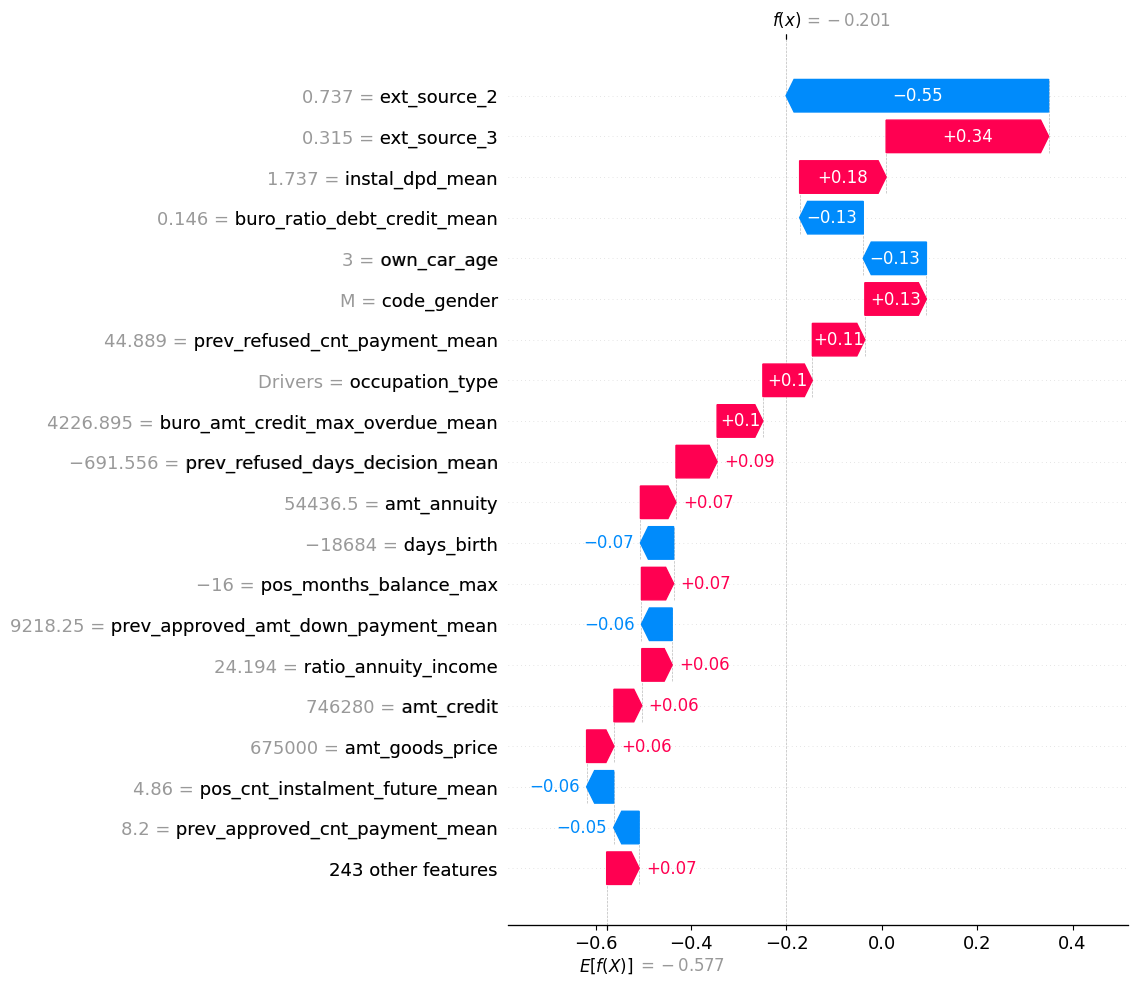

In [ ]:
# Selection of the instance to explain (base instance with index 0)
instance_index = 0

# Create an Explanation object from the SHAP values
shap_explanation = shap.Explanation(
    values=shap_values[instance_index, :],  # Use the SHAP values for the selected instance
    base_values=explainer.expected_value,  # Use the expected value from the explainer
    data=X_test_final.iloc[instance_index],  # Use the feature values for the selected instance
    feature_names=X_test_final.columns  # Use the feature names
)

# Setting the figure size for better readability
plt.figure(figsize=(12, 8))

# Creation of the waterfall plot for the selected instance
shap.waterfall_plot(shap_explanation, max_display=20)



### Differents types of instances

Since we made examples of studiying local feature importance, let study the differents types of individuals we can have in our dataset, for this we will take:

- the individual with the lowest probability to be in positive class (means a client who repays his debt '0') to know what variables leads to a '0' classification

- the individual with the highest probability to be a positive class (means a client who doesn't repay his debt '1') to know what variables leads to a '1' classification

- the false positives ((y_pred == 1) & (y_test == 0))

- the false negatives ((y_pred == 0) & (y_test == 1))


In [ ]:
def plot_shap_waterfall(shap_values, X_test, instance_index, n_features=20, figsize=(12, 8), 
                       title=None, show_feature_values=True, base_value=None):
    """
    Crée un waterfall plot personnalisé basé sur les valeurs SHAP pour une instance spécifique.
    
    Parameters:
    -----------
    shap_values : numpy.ndarray
        Valeurs SHAP calculées pour tous les exemples
    X_test : pandas.DataFrame
        Données de test contenant les valeurs des features
    instance_index : int
        Index de l'instance à expliquer
    n_features : int, optional (default=20)
        Nombre de features à afficher dans le graphique
    figsize : tuple, optional (default=(12, 8))
        Taille de la figure matplotlib
    title : str, optional (default=None)
        Titre du graphique
    show_feature_values : bool, optional (default=True)
        Si True, affiche les valeurs des features
    base_value : float, optional (default=None)
        Valeur de base (expected_value) de SHAP. Si None, sera calculée comme la moyenne des prédictions.
        
    Returns:
    --------
    fig : matplotlib.figure.Figure
        La figure matplotlib créée
    """
    # Extraction of SHAP values for the specific instance
    instance_shap_values = shap_values[instance_index]
    
    # Creation of a DataFrame with the features and their SHAP values
    contribution_df = pd.DataFrame({
        'Feature': X_test.columns,
        'SHAP Value': instance_shap_values,
        'Feature Value': X_test.iloc[instance_index].values,
        'Abs SHAP Value': np.abs(instance_shap_values)
    })
    
    # Sort by absolute value of SHAP values
    contribution_df = contribution_df.sort_values('Abs SHAP Value', ascending=False)
    
    # Selection of top features
    top_contributions = contribution_df.head(n_features).sort_values('SHAP Value', ascending=True)
    
    # Creating the figure
    fig, ax = plt.subplots(figsize=figsize)
    
    # Defining colors
    red_blue = LinearSegmentedColormap.from_list('red_blue', ['#FF4B4B', '#008FD5'])
    
    # Base value (if not provided)
    if base_value is None:
        base_value = np.mean([sv.sum() for sv in shap_values])
    
    # Calculation of positions for the waterfall
    values = top_contributions['SHAP Value'].values
    features = top_contributions['Feature'].values
    feature_values = top_contributions['Feature Value'].values
    
    # Initialization of positions
    positions = np.zeros(len(values) + 2)
    positions[0] = base_value
    positions[-1] = base_value + np.sum(values)
    
    # Calculation of intermediate positions
    for i in range(1, len(values)+1):
        positions[i] = positions[i-1] + values[i-1]
    
    # Creation of the waterfall plot
    for i in range(len(values)):
        # Color based on contribution direction
        color = red_blue(0.1 if values[i] < 0 else 0.9)
        
        # Contribution bar
        ax.barh(i+1, values[i], left=positions[i], color=color, alpha=0.8)
        
        # Feature text
        feature_text = features[i]
        if show_feature_values:
            if isinstance(feature_values[i], (int, float)):
                if abs(feature_values[i]) < 0.01:
                    val_str = f"{feature_values[i]:.5f}"
                elif abs(feature_values[i]) < 1:
                    val_str = f"{feature_values[i]:.3f}"
                else:
                    val_str = f"{feature_values[i]:.2f}"
            else:
                val_str = str(feature_values[i])
            
            feature_text += f" = {val_str}"
        
        ax.text(positions[i] + (0.02 * np.sign(values[i]) * abs(values[i]).max()), 
               i+1, feature_text, 
               va='center', ha='left' if values[i] >= 0 else 'right',
               fontsize=10)
    
    # Base line
    ax.axhline(0, color='black', linestyle='-', linewidth=1)
    
    # Connection lines
    for i in range(len(positions)-1):
        ax.plot([positions[i], positions[i]], [i-0.4, i+0.4], color='gray', linestyle='-', linewidth=0.5)
    
    # Configuration of the axes
    ax.set_yticks(range(1, len(values)+1))
    ax.set_yticklabels([f"Feature {i+1}" for i in range(len(values))])
    ax.set_ylim(0, len(values)+2)
    
    # Titles
    if title is None:
        title = f"SHAP Waterfall Plot - Instance {instance_index}"
    ax.set_title(title, fontsize=14)
    ax.set_xlabel('Impact sur la prédiction', fontsize=12)
    
    from scipy.special import expit
    # Final value legend
    final_value = positions[-1]
    ax.text(1.02, 0.98, f"Prédiction finale: {expit(final_value):.4f}", 
           transform=ax.transAxes, va='top', ha='left',
           bbox=dict(facecolor='white', alpha=0.8))
    
    plt.tight_layout()
    return fig


In [ ]:
# Get predictions and true values
y_pred = best_model.predict(X_test_final)
y_true = final_df_lightgbm.loc[X_test_final.index, 'TARGET']

# Identify false positives (predicted 1 but true 0)
false_positives = (y_pred == 1) & (y_true == 0)
fp_indices = np.where(false_positives)[0]  # False positive indices

# Identify false negatives (predicted 0 but true 1)
false_negatives = (y_pred == 0) & (y_true == 1)
fn_indices = np.where(false_negatives)[0]  # False negative indices

#### FP

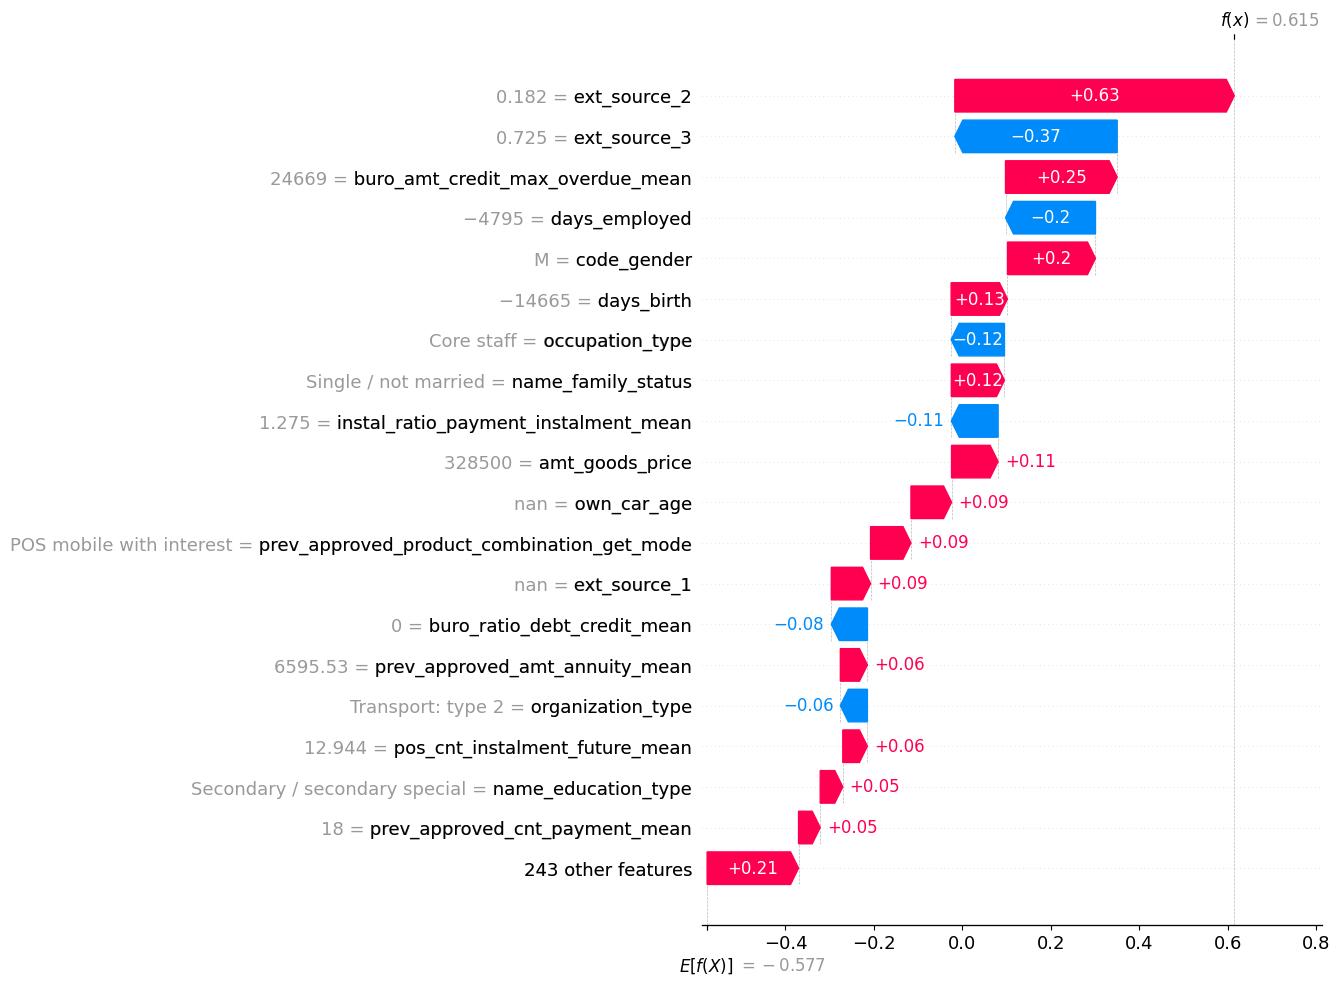

In [ ]:
# Pick one, e.g., the first one
fp_index = fp_indices[0]

# Create an Explanation object from the SHAP values
shap_explanation = shap.Explanation(
    values=shap_values[fp_index, :],  # Use the SHAP values for the selected instance
    base_values=explainer.expected_value,  # Use the expected value from the explainer
    data=X_test_final.iloc[fp_index],  # Use the feature values for the selected instance
    feature_names=X_test_final.columns  # Use the feature names
)

# Setting the figure size for better readability
plt.figure(figsize=(12, 8))

# Creation of the waterfall plot for the selected instance
shap.waterfall_plot(shap_explanation, max_display=20)

**Interpretation of the SHAP Waterfall Plot (false positive)**

**1. Global Prediction**
- **base value (E[f(X)])** : `-0.577`  
  → The average prediction of the model without features is **negative** (class 0 = "good customer" in this context).  
- **final prediction** : `~0.65`  
  → The model predicts **class 1** ("risk of default") for this instance.


**2. Key variables and their impact**  
| **Variable**                          | **Value**               | **SHAP Value** | **Impact**  |
|---------------------------------------|--------------------------|-----------------------------|-------------------------------------------------------------------------------------------------|
| **ext_source_3**                      | `0.725`                  | `-0.37`        | High external score   **strongly increases risk** (a non-majority case because there are high values that cause negative predictions according to the previous global summary plot).|
| **ext_source_2**                      | `0.182`                  | `+0.63`        | External score low slight increase in risk.| 
| **buro_amt_credit_max_overdue_mean**  | `24 669`                 | `+0.25`        | Very high debt arrears → **main cause of risk**.|
| **days_employed**                     | `-4 795` (jours)         | `-0.2`         | Reduces the risk.|
| **code_gender**                       | `M` (homme)              |  `+0.2`        | Increases the risk.|
| **days_birth**                        | `-14 665` (jours)        | `+0.13`      | High age (40 years) → reduces the risk.|
**243 other features**                  |                          | `+0.21`       | slight increase in risk|



**3. What caused this False Positive?**  
(predict "risk" but true label = "safe") :  

- The overdue debt (`buro_amt_credit_max_overdue_mean`) et `ext_source_2` overestimate the risk.

#### FN

Number of false negatives: 1505


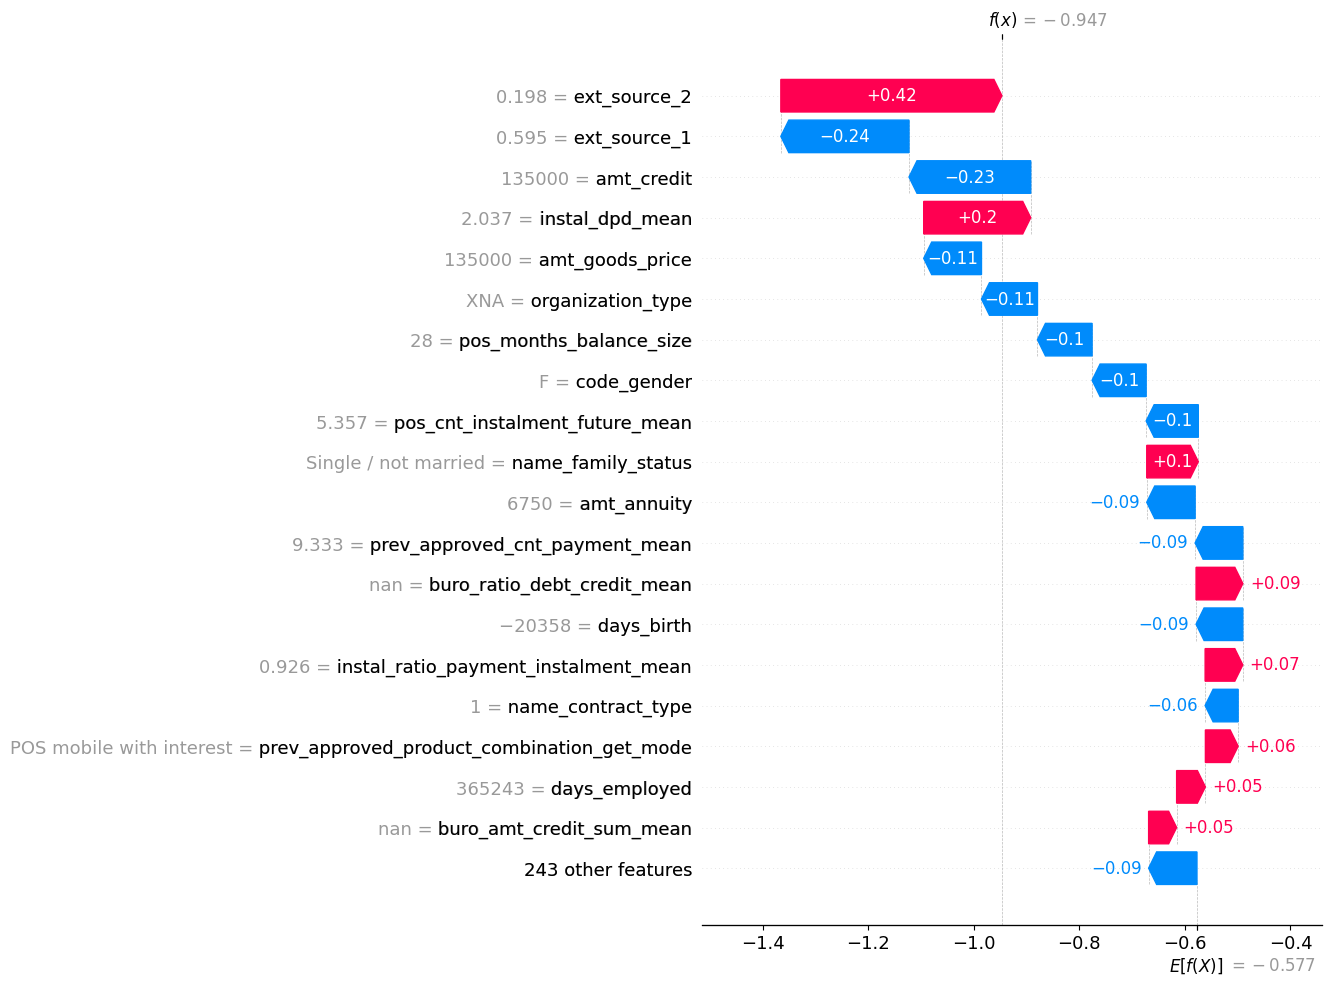

In [ ]:
# Find false negatives
false_negatives = (y_test == 1) & (y_pred == 0)
fn_indices = np.where(false_negatives)[0]

# Show how many
print(f"Number of false negatives: {len(fn_indices)}")

# Select the first false negative (or any index you want)
fn_index = fn_indices[0]

# Create an Explanation object from the SHAP values
shap_explanation = shap.Explanation(
    values=shap_values[fn_index, :],  # Use the SHAP values for the selected instance
    base_values=explainer.expected_value,  # Use the expected value from the explainer
    data=X_test_final.iloc[fn_index],  # Use the feature values for the selected instance
    feature_names=X_test_final.columns  # Use the feature names
)

# Setting the figure size for better readability
plt.figure(figsize=(12, 8))

# Creation of the waterfall plot for the selected instance
shap.waterfall_plot(shap_explanation, max_display=20)

**What caused this False Negative?**  
(predicted "safe" but it's truely = "risqy") :  

- (`amt_credit`) et `ext_source_1` reduce and conceal too much risk.  

#### Highest

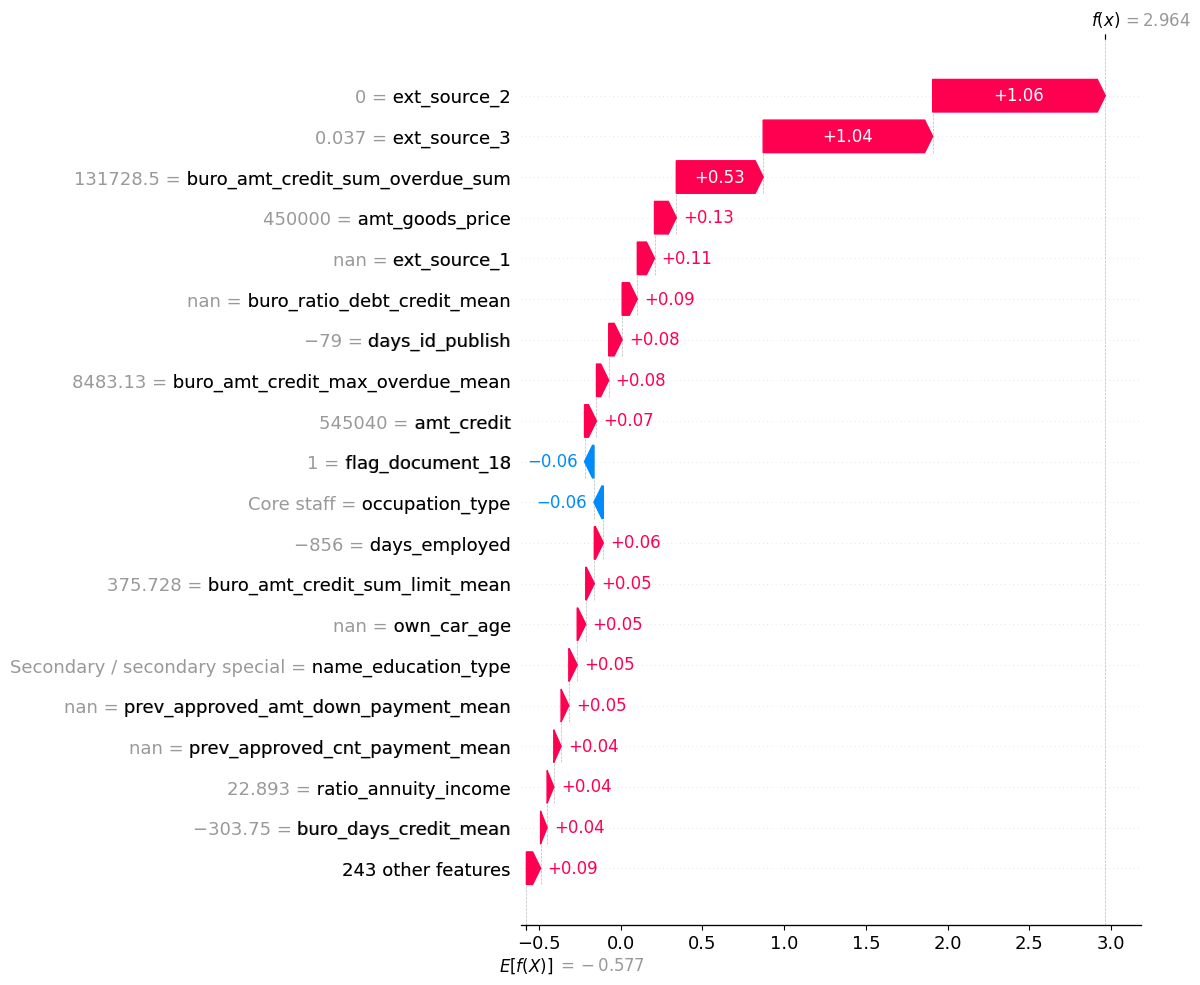

In [ ]:
y_proba = best_model.predict_proba(X_test_final)[:, 1]

highest_prob_idx = np.argmax(y_proba)

# Create an Explanation object from the SHAP values
shap_explanation = shap.Explanation(
    values=shap_values[highest_prob_idx, :],  # Use the SHAP values for the selected instance
    base_values=explainer.expected_value,  # Use the expected value from the explainer
    data=X_test_final.iloc[highest_prob_idx],  # Use the feature values for the selected instance
    feature_names=X_test_final.columns  # Use the feature names
)

# Setting the figure size for better readability
plt.figure(figsize=(12, 8))

# Creation of the waterfall plot for the selected instance
shap.waterfall_plot(shap_explanation, max_display=20)

#### Lowest

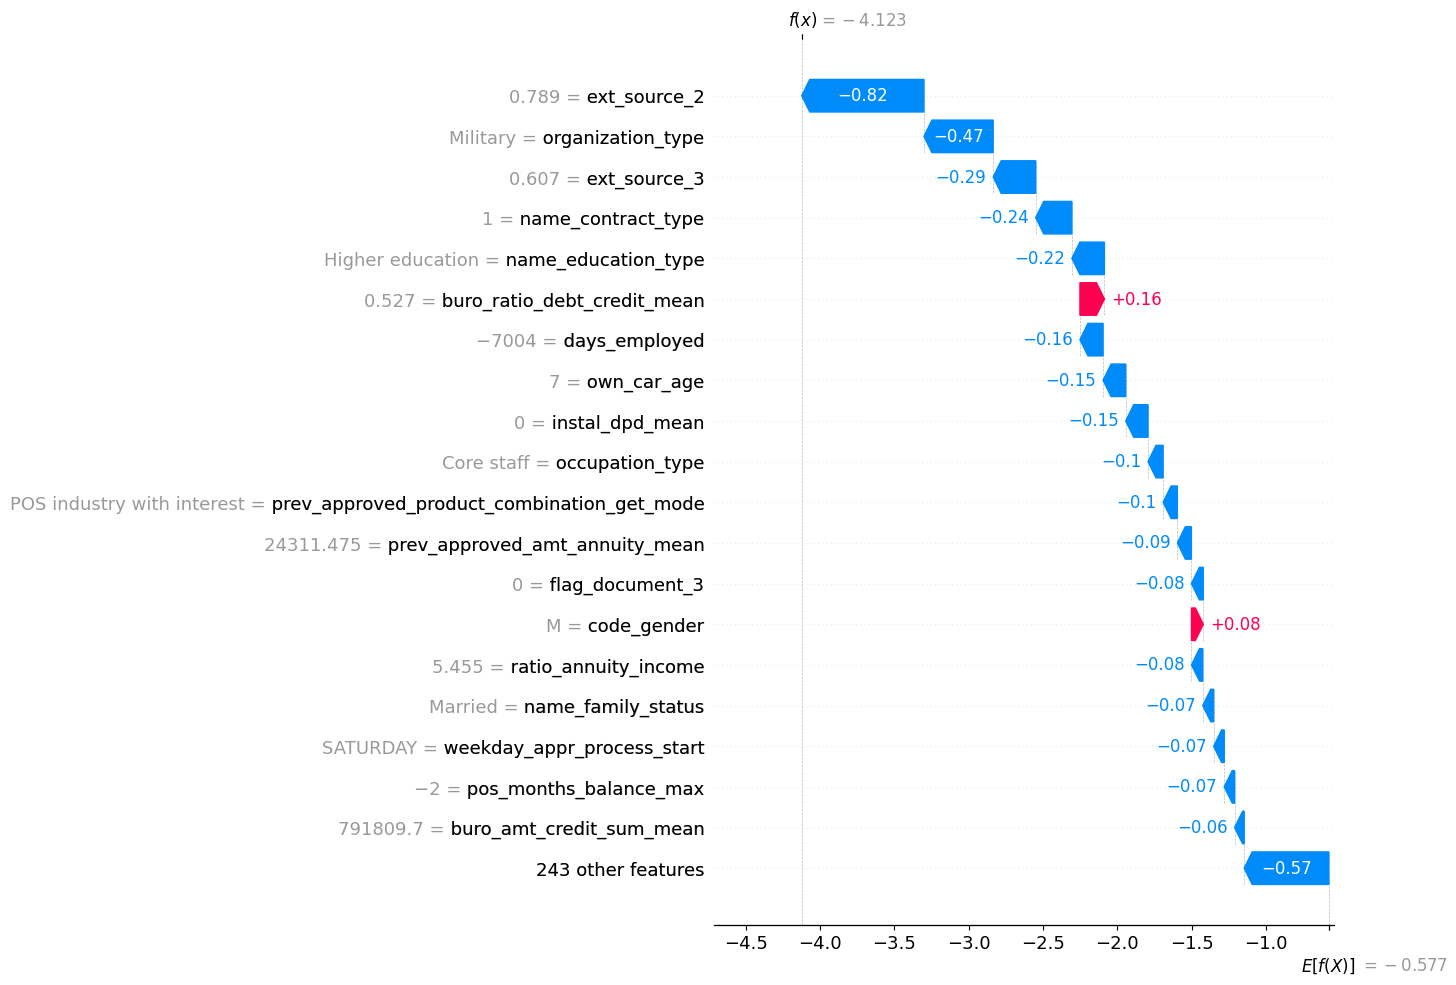

In [ ]:

lowest_prob_idx = np.argmin(y_proba)

# Create an Explanation object from the SHAP values
shap_explanation = shap.Explanation(
    values=shap_values[lowest_prob_idx, :],  # Use the SHAP values for the selected instance
    base_values=explainer.expected_value,  # Use the expected value from the explainer
    data=X_test_final.iloc[lowest_prob_idx],  # Use the feature values for the selected instance
    feature_names=X_test_final.columns  # Use the feature names
)

# Setting the figure size for better readability
plt.figure(figsize=(12, 8))

# Creation of the waterfall plot for the selected instance
shap.waterfall_plot(shap_explanation, max_display=20)



# End

Thank you for reading.